## Figure 6 from hparams-mode linguistic outputs


relations: ['word first letter', 'word last letter', 'adjective antonym', 'adjective superlative', 'verb past tense', 'adjective comparative']
faithfulness: [0.79741379 0.82352941 0.18461538 0.61971831 0.17910448 0.        ]
causality: [0.86425339 0.85714286 0.74603175 0.8        0.57377049 0.70833333]
Correlation: 0.81


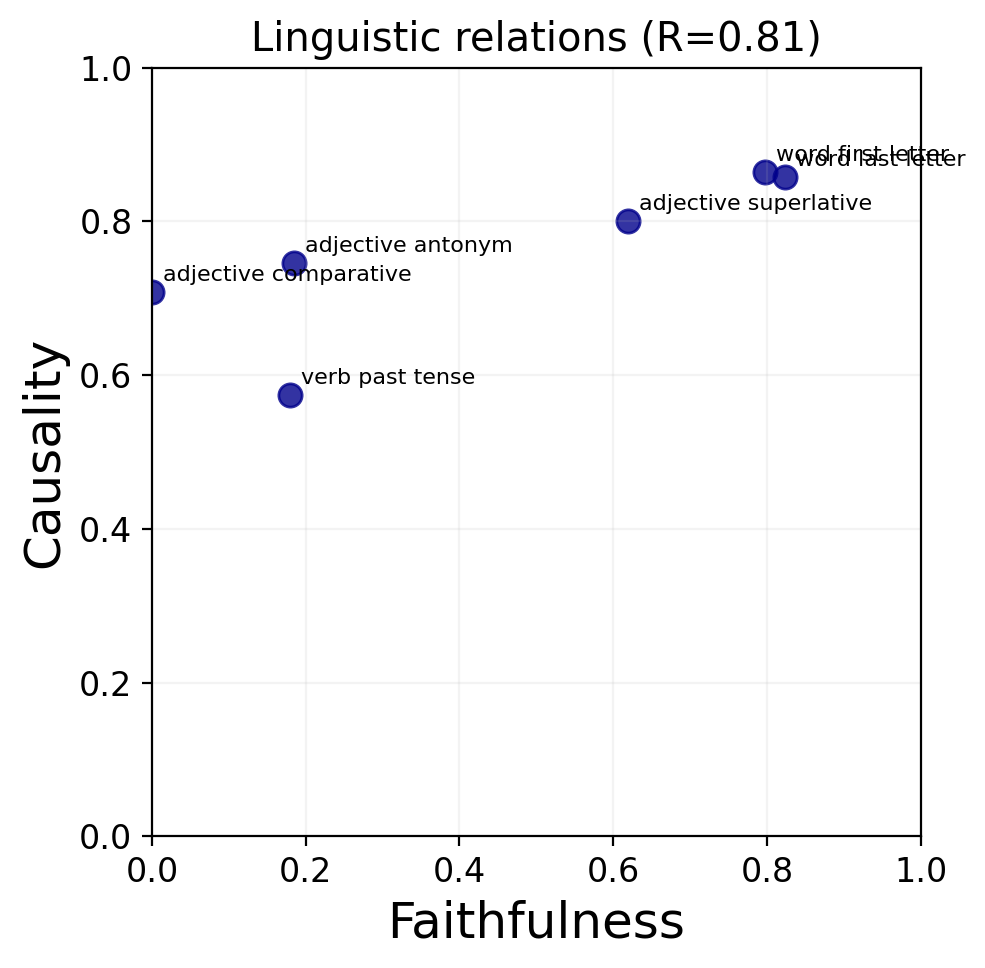

In [1]:
import os
import sys
from pathlib import Path

sys.path.append("../..")

import numpy as np
import matplotlib.pyplot as plt

from scripts.baselines.faithfulness_baselines import load_raw_results
from src.utils.sweep_utils import (
    format_efficacy_baseline_results,
    read_efficacy_baseline_results,
)

model_name = "gptj"
faithfulness_path = "../../results/faithfulness_baselines_updated"
if not (Path(faithfulness_path) / f"{model_name}.json").exists():
    faithfulness_path = "../../results/faithfulness_baselines"

efficacy_path = "../../results/efficacy_baselines-hparams/gptj"
fig_dir = Path("figs/gptj")
fig_dir.mkdir(parents=True, exist_ok=True)

linguistic_relations = [
    "word first letter",
    "word last letter",
    "adjective antonym",
    "adjective superlative",
    "verb past tense",
    "adjective comparative",
]

faithfulness_raw = load_raw_results(model_name, results_path=faithfulness_path)
faithfulness_by_relation = {}
for relation_result in faithfulness_raw:
    relation_name = relation_result["relation_name"]
    if relation_name not in linguistic_relations:
        continue

    trial_scores = []
    for trial in relation_result["trials"]:
        recall = trial.get("icl", {}).get("lre", {}).get("recall")
        if recall:
            trial_scores.append(recall[0])

    if trial_scores:
        faithfulness_by_relation[relation_name] = float(np.mean(trial_scores))

causality_raw = read_efficacy_baseline_results(efficacy_path)
causality_by_relation = {}
for relation_name, raw_result in causality_raw.items():
    if relation_name not in linguistic_relations:
        continue

    formatted = format_efficacy_baseline_results(raw_result)
    layerwise = formatted["layerwise_result"]
    layer = list(layerwise.keys())[0]
    causality_by_relation[relation_name] = layerwise[layer]["low_rank_pinv"].mean

relations = [
    relation
    for relation in linguistic_relations
    if relation in faithfulness_by_relation and relation in causality_by_relation
]
faithfulness = np.array([faithfulness_by_relation[relation] for relation in relations])
causality = np.array([causality_by_relation[relation] for relation in relations])

print("relations:", relations)
print("faithfulness:", faithfulness)
print("causality:", causality)

correlation = np.corrcoef(faithfulness, causality)[0, 1] if len(relations) > 1 else np.nan
print(f"Correlation: {correlation:.2f}")

plt.rcdefaults()
plt.rcParams["figure.dpi"] = 200
# plt.rcParams["font.family"] = "Times New Roman"
plt.rc("font", size=12)
plt.rc("axes", labelsize=18)
plt.rc("xtick", labelsize=12)
plt.rc("ytick", labelsize=12)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(faithfulness, causality, color="darkblue", alpha=0.8, s=70)

for relation, x, y in zip(relations, faithfulness, causality):
    ax.annotate(relation, (x, y), xytext=(4, 4), textcoords="offset points", fontsize=8)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Faithfulness")
ax.set_ylabel("Causality")
ax.set_title(f"Linguistic relations (R={correlation:.2f})")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.15)
fig.tight_layout()
fig.savefig(fig_dir / "gptj-fig6-linguistic-hparams.pdf", bbox_inches="tight")
plt.show()

